In [1]:
# Purpose: Import the PySpark DataFrame, ML, evaluation, plotting, and utility components used in this stage.
from pyspark.sql import functions as F
from pyspark.sql.types import (ArrayType, MapType, StructType)
from pyspark.storagelevel import StorageLevel
from pyspark.ml import Pipeline
from pyspark.ml.feature import (StringIndexer, OneHotEncoder, Imputer, VectorAssembler,
    StandardScaler
)
from pyspark.ml.functions import vector_to_array
from pyspark.ml.regression import (
    LinearRegression,
    RandomForestRegressor,
    GBTRegressor
)
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd
import matplotlib.pyplot as plt
SEED = 42

In [59]:
# Purpose: Define the GCS input, output, vector, and model locations used by this stage.
NORMALIZED_SPARK_ROOT = ("gs://federal-contracts/staging/" "federal_contracts_uuid_normalized/v1/")
SILVER_ROOT = ("gs://federal-contracts/silver/" "contracts_ml/v1")


In [3]:
# Purpose: Configure Spark shuffle partitioning for the distributed Big Data workload.
spark.conf.set("spark.sql.shuffle.partitions", "192")

In [4]:
# Purpose: Load the required Parquet data into `contracts_df` for this Big Data processing stage.
contracts_df = (spark.read.parquet("gs://federal-contracts/silver/federal_contracts_cleaned/v1/"))

In [5]:
# Purpose: Aggregate the Spark data to produce summary statistics for this analysis.
contracts_df.groupby().count().show()

+--------+
|   count|
+--------+
|26783674|
+--------+



## Number cols and rows after removing the old dates

In [7]:
# Purpose: Check the dataset width and basic row/column dimensions.
print("Total rows:",f"{contracts_df.count():,}")
print("Columns:",len(contracts_df.columns))

Total rows: 26,783,674
Columns: 58


## selecting the important cols

In [8]:
# Purpose: Define the project columns used for schema validation, cleaning, feature engineering, or analysis.
ANALYSIS_COLUMNS = [
    # IDs
    "id", "award_id", "piid", "parent_award_piid",
    # contract
    "award_type", "extent_competed", "solicitation_procedures", "type_of_set_aside",
    # agencies
    "awarding_agency_code", "awarding_agency_name", "awarding_subagency_code",
    "funding_agency_name",
    # industry
    "naics_code",
    "psc_code",
    # recipient / performance location
    "recipient_state",
    "recipient_country",
    "pop_state",
    "pop_country",
    "recipient_name",
    "recipient_name_normalized",
    # business information
    "small_business_flag",
    "woman_owned_flag",
    "veteran_owned_flag",
    "minority_owned_flag",
    # monetary values
    "base_and_all_options_value",
    "total_obligation",
    "federal_action_obligation",
    # target
    "number_of_offers_received",
    # dates
    "action_date",
    "period_of_performance_start",
    "period_of_performance_end",
    # year
    "fiscal_year",
    "source_year"
]

In [9]:
# Purpose: Check the dataset width and basic row/column dimensions.
full_selected = (contracts_df.select(*ANALYSIS_COLUMNS))
print("Analysis columns:",len(full_selected.columns))

Analysis columns: 33


# PART A — FULL-DATA EDA

In [10]:
# Purpose: Define `null_report_fast` to calculate column-level null and empty-value statistics efficiently.
def null_report_fast(df):
    expressions = [F.count("*").alias("__total_rows")]
    for field in df.schema.fields:
        c = field.name
        condition = (F.col(c).isNull())
        #EMPTY STRING AND NULL VALUES 
        if (field.dataType.simpleString()== "string"):
            condition = (condition|(F.trim(F.col(c)) == ""))
        expressions.append(F.sum(F.when(condition,1).otherwise(0)).alias(c))
    result = (df.agg(*expressions).first())
    total = result["__total_rows"]
    rows = []
    for c in df.columns:
        missing = int(result[c] or 0)
        rows.append((c,missing,round(missing/ total* 100,2)))
    return spark.createDataFrame(rows,["column","missing_count","missing_percent"])

In [11]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
null_before = null_report_fast(full_selected).orderBy(F.desc("missing_percent"))
null_before.show(50,truncate=False)

26/08/20 16:45:29 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---------------------------+-------------+---------------+
|column                     |missing_count|missing_percent|
+---------------------------+-------------+---------------+
|woman_owned_flag           |25957256     |96.91          |
|veteran_owned_flag         |25957256     |96.91          |
|minority_owned_flag        |25957256     |96.91          |
|type_of_set_aside          |20428142     |76.27          |
|number_of_offers_received  |17846210     |66.63          |
|small_business_flag        |13237903     |49.43          |
|parent_award_piid          |5249136      |19.6           |
|award_type                 |4856585      |18.13          |
|pop_state                  |1785275      |6.67           |
|period_of_performance_end  |971490       |3.63           |
|pop_country                |972029       |3.63           |
|recipient_state            |587265       |2.19           |
|total_obligation           |492269       |1.84           |
|extent_competed            |122677     

## ploting the all columns based on null counts

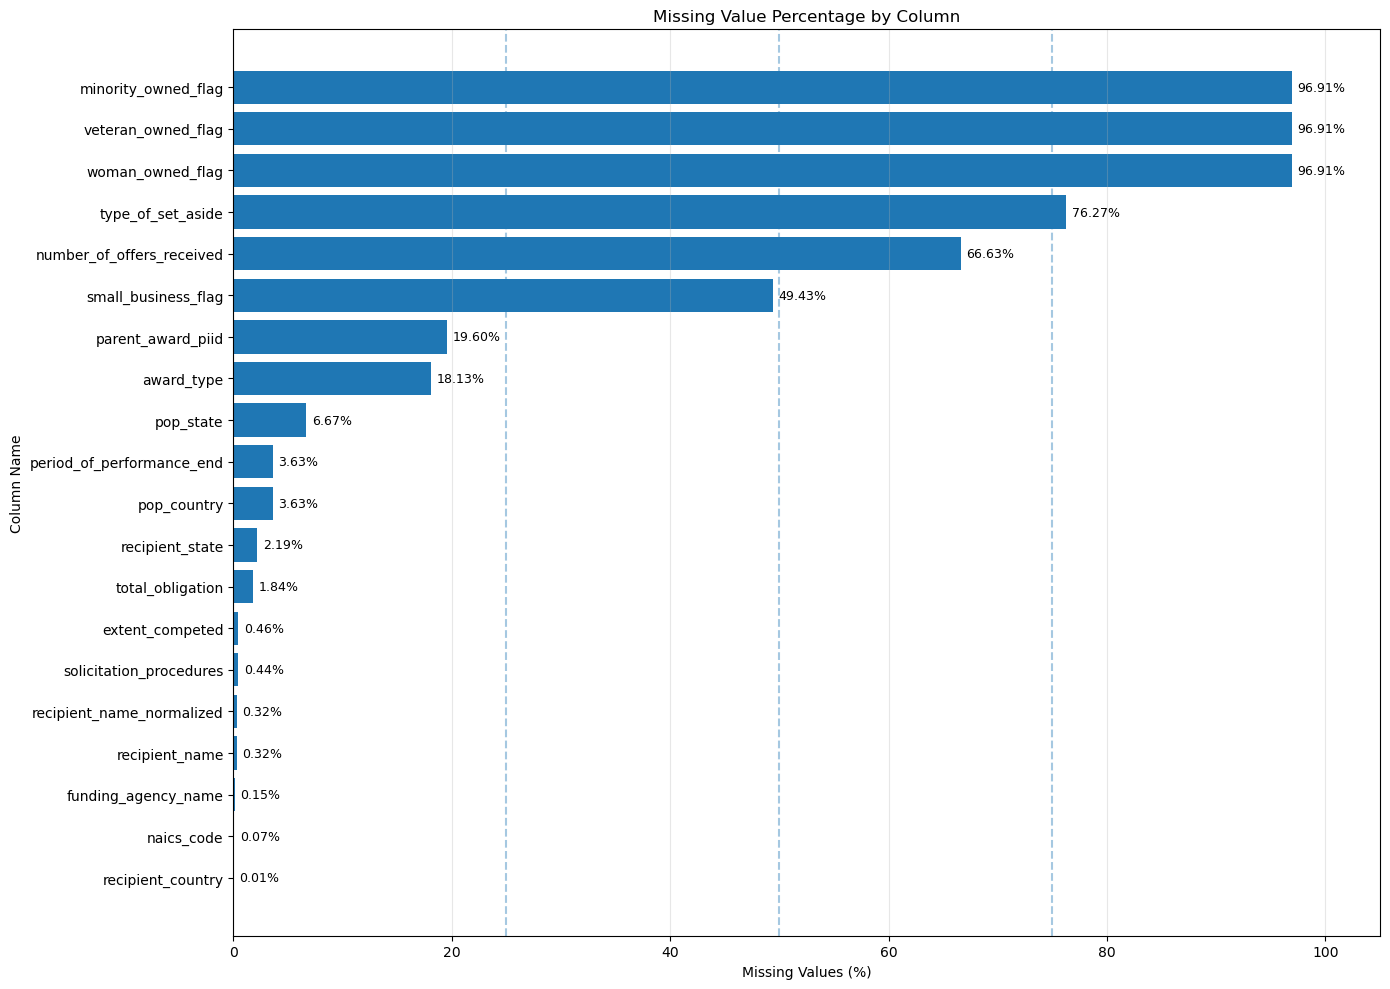

In [12]:
# Purpose: Import the Python and PySpark utilities required for this notebook stage.
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
# Remove columns with 0% missing values
null_plot_df = (null_before.filter(F.col("missing_percent") > 0).orderBy("missing_percent"))
# Small summary table -> Pandas
null_pdf = null_plot_df.toPandas()
# Plot
fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(null_pdf["column"],null_pdf["missing_percent"])
# Add percentage labels
for bar, value in zip(bars,null_pdf["missing_percent"]):
    ax.text(value + 0.5, bar.get_y() + bar.get_height() / 2, f"{value:.2f}%", va="center", fontsize=9)
ax.set_title("Missing Value Percentage by Column")
ax.set_xlabel("Missing Values (%)")
ax.set_ylabel("Column Name")
# Percentage scale
ax.set_xlim(0, 105)
# Reference lines
ax.axvline(25,linestyle="--",alpha=0.4)
ax.axvline(50,linestyle="--",alpha=0.4)
ax.axvline(75,linestyle="--",alpha=0.4)
ax.grid(axis="x",alpha=0.3)
plt.tight_layout()
plt.show()

## Removing the clos that more null values

In [13]:
# Purpose: Prepare `owned_flag_cols` for the next Big Data processing, analysis, or modeling step.
owned_flag_cols = ["woman_owned_flag", "veteran_owned_flag", "minority_owned_flag"]
contracts_df = full_selected.drop(*owned_flag_cols)

In [14]:
# Purpose: Execute the code for the notebook section: Removing the clos that more null values.
print(contracts_df.columns)

['id', 'award_id', 'piid', 'parent_award_piid', 'award_type', 'extent_competed', 'solicitation_procedures', 'type_of_set_aside', 'awarding_agency_code', 'awarding_agency_name', 'awarding_subagency_code', 'funding_agency_name', 'naics_code', 'psc_code', 'recipient_state', 'recipient_country', 'pop_state', 'pop_country', 'recipient_name', 'recipient_name_normalized', 'small_business_flag', 'base_and_all_options_value', 'total_obligation', 'federal_action_obligation', 'number_of_offers_received', 'action_date', 'period_of_performance_start', 'period_of_performance_end', 'fiscal_year', 'source_year']


In [27]:
# Purpose: Define the GCS input, output, vector, and model locations used by this stage.
UNDER_PROCESSING_PATH = ("gs://federal-contracts/under_processing/contracts_cleaned_v1")
contracts_df.write.mode("overwrite").parquet(UNDER_PROCESSING_PATH)

In [15]:
# Purpose: Load the required Parquet dataset from GCS into Spark.
##LAODING THE DATA FROM UNDER_PREPROCESSING
contracts_df =spark.read.parquet("gs://federal-contracts/under_processing/contracts_cleaned_v1")


## 5. EDA — contracts per year

In [16]:
# Purpose: Aggregate contract records by year to inspect temporal coverage and target availability.
yearly_counts = contracts_df.groupBy("source_year").count().orderBy("source_year")
yearly_counts.show()

+-----------+-------+
|source_year|  count|
+-----------+-------+
|       2009|  31688|
|       2010| 167857|
|       2011|  75313|
|       2012|  68367|
|       2013|  63733|
|       2014|  73080|
|       2015|  68165|
|       2016|  72640|
|       2017|  80728|
|       2018|  76422|
|       2019|1381001|
|       2020|6297347|
|       2021|5000361|
|       2022|1383308|
|       2023|6751368|
|       2024|5192296|
+-----------+-------+



In [17]:
# Purpose: Prepare `year_pdf` for the next Big Data processing, analysis, or modeling step.
year_pdf = (yearly_counts.toPandas())

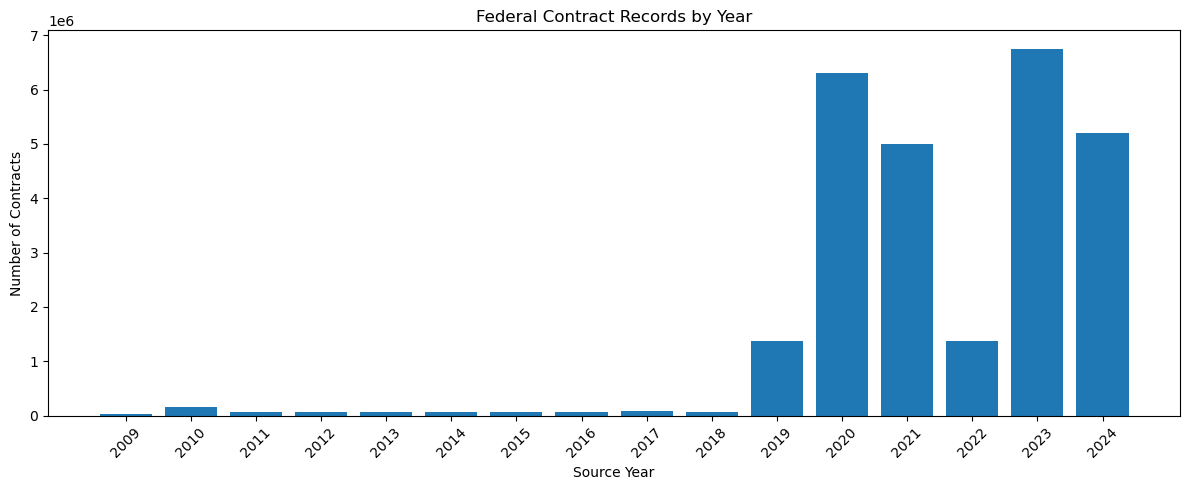

In [18]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
plt.figure(figsize=(12, 5))
plt.bar(year_pdf["source_year"].astype(str),year_pdf["count"])
plt.title("Federal Contract Records by Year")
plt.xlabel("Source Year")
plt.ylabel("Number of Contracts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## EDA — target availability by year

In [19]:
# Purpose: Run the notebook SQL query against the registered contract data.
%sql select * from contracts_df

UsageError: Line magic function `%sql` not found.


In [22]:
# Purpose: Apply the required Spark column transformation for cleaning or feature engineering.
target_availability = (contracts_df.groupBy("source_year").agg(F.count("*").alias("records"),
        F.count(F.when(F.col("number_of_offers_received") >= 0,1)).alias("offers_available"),
        F.count(F.when(F.col("base_and_all_options_value") > 0,1)).alias("award_value_available")
    ).withColumn("offers_available_pct",F.round(F.col("offers_available") / F.col("records") * 100,2))
    .withColumn("award_value_available_pct",F.round(F.col("award_value_available") / F.col("records") * 100,2)
    ).orderBy("source_year"))
target_availability.show()

+-----------+-------+----------------+---------------------+--------------------+-------------------------+
|source_year|records|offers_available|award_value_available|offers_available_pct|award_value_available_pct|
+-----------+-------+----------------+---------------------+--------------------+-------------------------+
|       2009|  31688|           31494|                19891|               99.39|                    62.77|
|       2010| 167857|          166780|               123510|               99.36|                    73.58|
|       2011|  75313|           74411|                53693|                98.8|                    71.29|
|       2012|  68367|           67518|                49203|               98.76|                    71.97|
|       2013|  63733|           61888|                45629|               97.11|                    71.59|
|       2014|  73080|           70840|                50771|               96.93|                    69.47|
|       2015|  68165|       

In [21]:
# Purpose: Apply the required Spark column transformation for cleaning or feature engineering.
target_availability = (contracts_df.groupBy("source_year").agg(F.count("*").alias("records"),F.sum(
            F.when(F.col("number_of_offers_received") >= 0,1).otherwise(0)).alias("offers_available"),
        F.sum(F.when(F.col("base_and_all_options_value") > 0,1).otherwise(0)).alias("award_value_available"))
    .withColumn("offers_available_pct",F.round(F.col("offers_available")/F.col("records")* 100,2)).withColumn(
        "award_value_available_pct",
        F.round(F.col("award_value_available")/F.col("records")* 100,2)).orderBy("source_year"))
target_availability.show()

+-----------+-------+----------------+---------------------+--------------------+-------------------------+
|source_year|records|offers_available|award_value_available|offers_available_pct|award_value_available_pct|
+-----------+-------+----------------+---------------------+--------------------+-------------------------+
|       2009|  31688|           31494|                19891|               99.39|                    62.77|
|       2010| 167857|          166780|               123510|               99.36|                    73.58|
|       2011|  75313|           74411|                53693|                98.8|                    71.29|
|       2012|  68367|           67518|                49203|               98.76|                    71.97|
|       2013|  63733|           61888|                45629|               97.11|                    71.59|
|       2014|  73080|           70840|                50771|               96.93|                    69.47|
|       2015|  68165|       

In [23]:
# Purpose: Prepare `target_pdf` for the next Big Data processing, analysis, or modeling step.
target_pdf = (target_availability.toPandas())

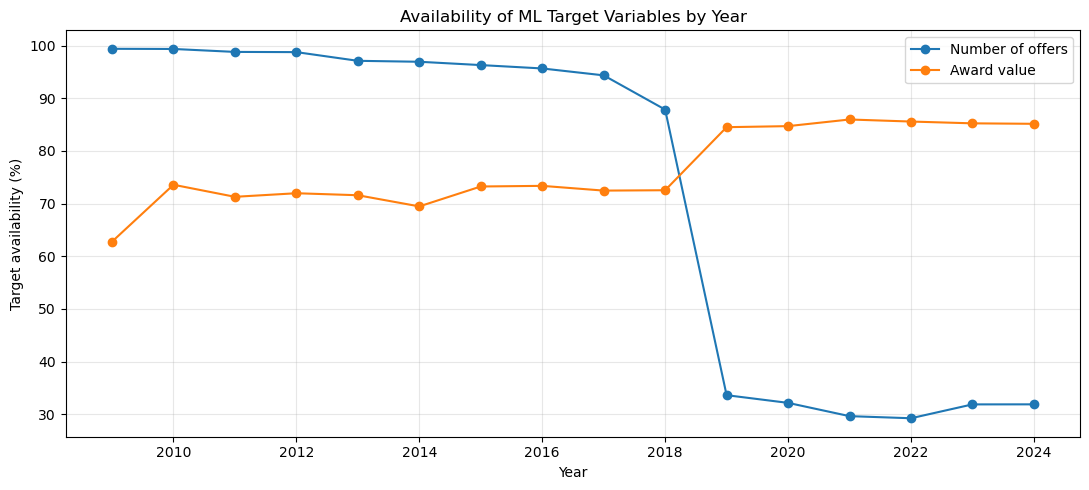

In [24]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
# Ploting the graph 
plt.figure(figsize=(11, 5))
plt.plot(target_pdf["source_year"],target_pdf["offers_available_pct"],marker="o",label="Number of offers")
plt.plot(target_pdf["source_year"],target_pdf["award_value_available_pct"],marker="o",label="Award value")
plt.xlabel("Year")
plt.ylabel("Target availability (%)")
plt.title("Availability of ML Target Variables by Year")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## EDA — number of offers distribution

In [26]:
# Purpose: Apply the required Spark column transformation for cleaning or feature engineering.
offers_distribution = (contracts_df.filter(F.col("number_of_offers_received") >= 0).withColumn("offers_bucket",
        F.when(F.col("number_of_offers_received") == 0,"0").when(F.col("number_of_offers_received") == 1,"1")
        .when(F.col("number_of_offers_received") == 2,"2").when(F.col("number_of_offers_received") <= 5,"3-5")
        .when(F.col("number_of_offers_received") <= 10,"6-10")
        .when(F.col("number_of_offers_received") <= 25,"11-25")
        .when(F.col("number_of_offers_received") <= 50,"26-50")
        .when(F.col("number_of_offers_received") <= 100,"51-100").otherwise("100+"))
.withColumn("bucket_order",F.when(F.col("offers_bucket") == "0", 1).when(F.col("offers_bucket") == "1", 2)
        .when(F.col("offers_bucket") == "2", 3).when(F.col("offers_bucket") == "3-5", 4)
        .when(F.col("offers_bucket") == "6-10", 5).when(F.col("offers_bucket") == "11-25", 6)
        .when(F.col("offers_bucket") == "26-50", 7)
        .when(F.col("offers_bucket") == "51-100", 8)
        .otherwise(9)
    ).groupBy("offers_bucket","bucket_order").count().orderBy("bucket_order")
)

In [27]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
offers_distribution.show()

+-------------+------------+-------+
|offers_bucket|bucket_order|  count|
+-------------+------------+-------+
|            0|           1|  32695|
|            1|           2|3508424|
|            2|           3|1020884|
|          3-5|           4|2051975|
|         6-10|           5| 785987|
|        11-25|           6| 718779|
|        26-50|           7| 201111|
|       51-100|           8|  34330|
|         100+|           9| 583279|
+-------------+------------+-------+



In [28]:
# Purpose: Prepare `offers_dist_pdf` for the next Big Data processing, analysis, or modeling step.
offers_dist_pdf = (offers_distribution.toPandas())

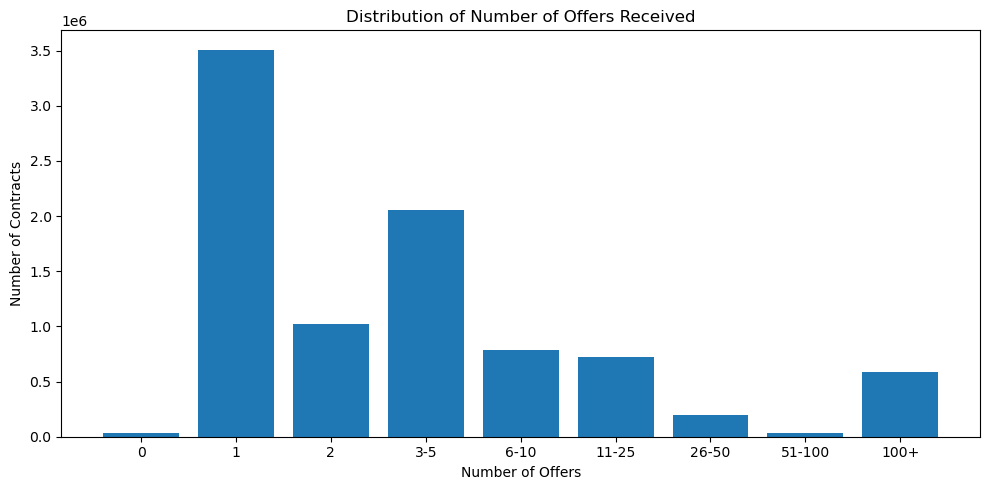

In [29]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
plt.figure(figsize=(10, 5))
plt.bar(offers_dist_pdf["offers_bucket"],offers_dist_pdf["count"])
plt.title("Distribution of Number of Offers Received")
plt.xlabel("Number of Offers")
plt.ylabel("Number of Contracts")
plt.tight_layout()
plt.show()

## Target statistical summary — offers

In [30]:
# Purpose: Calculate robust distribution statistics and approximate percentiles for the selected numeric field.
# Summary statistics for number of offers received: count, mean, percentiles, and maximum

offers_stats = (contracts_df.filter(F.col("number_of_offers_received") >= 0).agg(
        F.count("number_of_offers_received").alias("observations"),
        F.avg("number_of_offers_received").alias("mean"), F.expr("""
            percentile_approx(
                number_of_offers_received,
                array(0.25, 0.50, 0.75, 0.90, 0.95, 0.99)
            )
        """).alias("percentiles"), F.max("number_of_offers_received").alias("maximum")))

offers_stats.show(truncate=False)

+------------+-----------------+-----------------------+-------+
|observations|mean             |percentiles            |maximum|
+------------+-----------------+-----------------------+-------+
|8937464     |64.93036100620937|[1, 2, 6, 22, 999, 999]|999    |
+------------+-----------------+-----------------------+-------+



### base_and_all_options_value represents the potential total value of the contract, including:

Base contract value
Value of all contract options
base_and_all_options_value

In [28]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
contracts_df.agg(F.min('base_and_all_options_value')).show()

+-------------------------------+
|min(base_and_all_options_value)|
+-------------------------------+
|              -9.99999999999E11|
+-------------------------------+



In [31]:
# Purpose: Apply the required Spark column transformation for cleaning or feature engineering.
# Group positive award values into ordered dollar-value ranges and count the contracts in each range
award_distribution = (contracts_df.filter(F.col("base_and_all_options_value") > 0).withColumn("value_bucket",
        F.when(F.col("base_and_all_options_value") < 1_000, "< $1K")
        .when(F.col("base_and_all_options_value") < 10_000, "$1K-$10K")
        .when(F.col("base_and_all_options_value") < 100_000, "$10K-$100K")
        .when(F.col("base_and_all_options_value") < 1_000_000, "$100K-$1M")
        .when(F.col("base_and_all_options_value") < 10_000_000, "$1M-$10M").otherwise("$10M+")).withColumn(
        "bucket_order", F.when(F.col("value_bucket") == "< $1K", 1)
        .when(F.col("value_bucket") == "$1K-$10K", 2)
        .when(F.col("value_bucket") == "$10K-$100K", 3)
        .when(F.col("value_bucket") == "$100K-$1M", 4)
        .when(F.col("value_bucket") == "$1M-$10M", 5)
        .otherwise(6)
    )
    .groupBy("value_bucket", "bucket_order")
    .count()
    .orderBy("bucket_order")
)

In [32]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
award_distribution.show()

+------------+------------+--------+
|value_bucket|bucket_order|   count|
+------------+------------+--------+
|       < $1K|           1|13817744|
|    $1K-$10K|           2| 4914097|
|  $10K-$100K|           3| 2722367|
|   $100K-$1M|           4|  937702|
|    $1M-$10M|           5|  254942|
|       $10M+|           6|   73466|
+------------+------------+--------+



In [33]:
# Purpose: Prepare `award_pdf` for the next Big Data processing, analysis, or modeling step.
award_pdf = (award_distribution.toPandas())

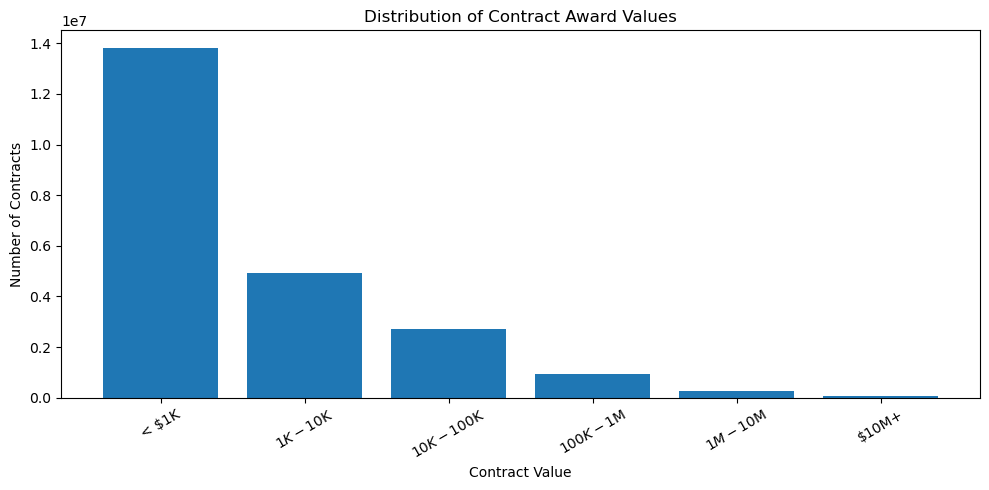

In [34]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
# Plot the distribution of contracts across the different award value ranges
plt.figure(figsize=(10, 5))
plt.bar(award_pdf["value_bucket"], award_pdf["count"])
plt.title("Distribution of Contract Award Values")
plt.xlabel("Contract Value")
plt.ylabel("Number of Contracts")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Award-value percentiles

In [35]:
# Purpose: Calculate robust distribution statistics and approximate percentiles for the selected numeric field.
# Summary statistics for positive contract award values: count, mean, percentiles, and maximum
award_stats = (contracts_df.filter(F.col("base_and_all_options_value") > 0).agg(
        F.count("*").alias("observations"), F.avg("base_and_all_options_value").alias("mean"), F.expr("""
            percentile_approx(
                base_and_all_options_value,
                array(0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999)
            )
        """).alias("percentiles"), F.max("base_and_all_options_value").alias("maximum")))

award_stats.show(truncate=False)

+------------+-------------------+---------------------------------------------------------------------+------------------+
|observations|mean               |percentiles                                                          |maximum           |
+------------+-------------------+---------------------------------------------------------------------+------------------+
|22720318    |6.756686940686682E7|[144.11, 526.31, 3764.75, 31833.0, 124038.69, 1860323.0, 6.3043117E7]|9.9999999999999E11|
+------------+-------------------+---------------------------------------------------------------------+------------------+



## EDA — offers and award value over time

In [36]:
# Purpose: Engineer and validate contract duration as a derived numeric feature.
# Create EDA features for NAICS sector, PSC group, and contract duration in days
eda_df = (contracts_df.withColumn("naics2", F.when(F.length(F.trim("naics_code")) >= 2,
            F.substring(F.trim("naics_code"), 1, 2))).withColumn(
        "psc2",
        F.when(
            F.length(F.trim("psc_code")) >= 2,
            F.substring(F.trim("psc_code"), 1, 2)
        )
    )
    .withColumn(
        "duration_days",
        F.datediff(
            F.col("period_of_performance_end"),
            F.col("period_of_performance_start")
        )
    )
)

In [37]:
# Purpose: Aggregate contract records by year to inspect temporal coverage and target availability.
# Calculate yearly average and median offers received, plus the median positive contract award value
yearly_targets = (eda_df.groupBy("source_year").agg(F.avg(F.when(F.col("number_of_offers_received") >= 0,
                F.col("number_of_offers_received"))).alias("avg_offers"),

        F.expr("""
            percentile_approx(
                CASE
                    WHEN number_of_offers_received >= 0
                    THEN number_of_offers_received
                END,
                0.5
            )
        """).alias("median_offers"),

        F.expr("""
            percentile_approx(
                CASE
                    WHEN base_and_all_options_value > 0
                    THEN base_and_all_options_value
                END,
                0.5
            )
        """).alias("median_award_value")
    )
    .orderBy("source_year")
)

In [38]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
yearly_targets.show()

+-----------+------------------+-------------+------------------+
|source_year|        avg_offers|median_offers|median_award_value|
+-----------+------------------+-------------+------------------+
|       2009| 2.499174445926208|            1|            8000.0|
|       2010|2.8122136946876126|            1|          10065.63|
|       2011| 3.389660130894626|            1|            8778.0|
|       2012|3.4789833822091887|            1|            9971.2|
|       2013| 5.162955661840744|            1|           10000.0|
|       2014| 4.357439299830604|            1|          10463.16|
|       2015|6.4578706031107656|            1|          10500.38|
|       2016| 6.805255356808796|            1|            9733.0|
|       2017|14.713098504640996|            1|           11919.0|
|       2018|20.931291797613905|            1|          14059.82|
|       2019| 64.42848652803886|            2|            487.49|
|       2020| 77.15323574182773|            2|            462.77|
|       20

In [39]:
# Purpose: Prepare `year_targets_pdf` for the next Big Data processing, analysis, or modeling step.
year_targets_pdf = (yearly_targets.toPandas())

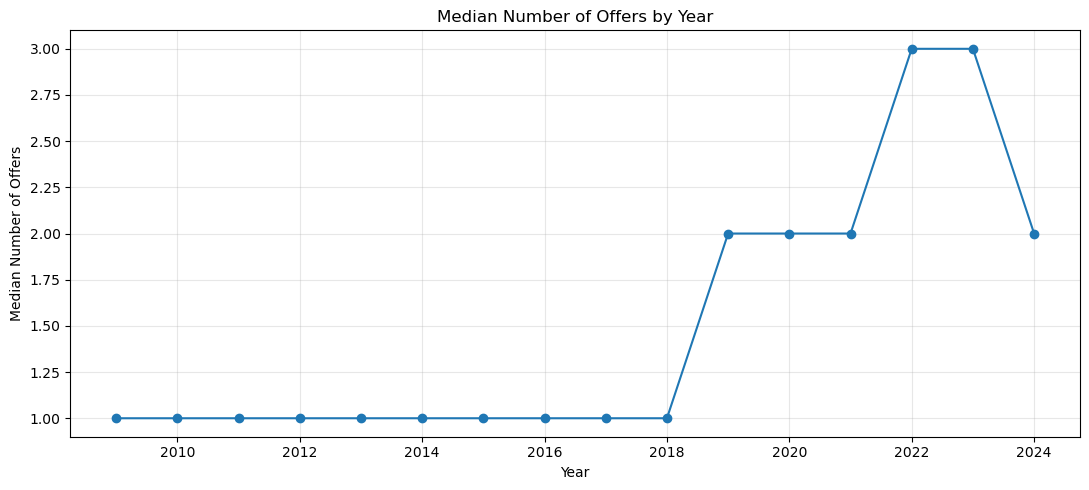

In [40]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
# Plot the yearly trend in the median number of offers received
plt.figure(figsize=(11, 5))
plt.plot(year_targets_pdf["source_year"], year_targets_pdf["median_offers"], marker="o")
plt.title("Median Number of Offers by Year")
plt.xlabel("Year")
plt.ylabel("Median Number of Offers")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## EDA — top NAICS sectors

In [41]:
# Purpose: Engineer compact NAICS and PSC category features for analysis and modeling.
# Summarize the top 15 NAICS sectors by contract count, offers received, and median award value
top_naics = (eda_df.withColumn("naics2", F.coalesce(F.col("naics2"), F.lit("__UNKNOWN__"))).groupBy("naics2")
    .agg(F.count("*").alias("contracts"),

        F.avg(F.when(
                F.col("number_of_offers_received") >= 0,
                F.col("number_of_offers_received")
            )
        ).alias("avg_offers"),

        F.expr("""
            percentile_approx(
                CASE
                    WHEN number_of_offers_received >= 0
                    THEN number_of_offers_received
                END,
                0.5
            )
        """).alias("median_offers"),

        F.expr("""
            percentile_approx(
                CASE
                    WHEN base_and_all_options_value > 0
                    THEN base_and_all_options_value
                END,
                0.5
            )
        """).alias("median_value")
    )
    .orderBy(F.desc("contracts"))
    .limit(15)
)

In [42]:
# Purpose: Execute the code for the notebook section: EDA — top NAICS sectors.
# NAICS 2-digit sector mapping
naics_sector_map = {"11": "Agriculture, Forestry, Fishing and Hunting",
    "21": "Mining, Quarrying, and Oil and Gas Extraction", "22": "Utilities", "23": "Construction",
    "31": "Manufacturing", "32": "Manufacturing", "33": "Manufacturing", "42": "Wholesale Trade",
    "44": "Retail Trade", "45": "Retail Trade", "48": "Transportation and Warehousing",
    "49": "Transportation and Warehousing",
    "51": "Information",
    "52": "Finance and Insurance",
    "53": "Real Estate and Rental and Leasing",
    "54": "Professional, Scientific, and Technical Services",
    "55": "Management of Companies and Enterprises",
    "56": "Administrative and Support and Waste Management",
    "61": "Educational Services",
    "62": "Health Care and Social Assistance",
    "71": "Arts, Entertainment, and Recreation",
    "72": "Accommodation and Food Services",
    "81": "Other Services",
    "92": "Public Administration"
}

In [43]:
# Purpose: Prepare `naics_map_expr` for the next Big Data processing, analysis, or modeling step.
naics_map_expr = F.create_map(*[item for k, v in naics_sector_map.items() for item in (F.lit(k), F.lit(v))])

In [44]:
# Purpose: Engineer compact NAICS and PSC category features for analysis and modeling.
top_naics_named = (top_naics.withColumn("sector_name", naics_map_expr[F.col("naics2")]))

In [46]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
top_naics_named.show(truncate=False)

+------+---------+------------------+-------------+------------+------------------------------------------------+
|naics2|contracts|avg_offers        |median_offers|median_value|sector_name                                     |
+------+---------+------------------+-------------+------------+------------------------------------------------+
|33    |6788410  |45.26064413044624 |2            |568.26      |Manufacturing                                   |
|42    |5391137  |78.03150802535119 |22           |333.3       |Wholesale Trade                                 |
|31    |4016394  |45.73288371587077 |2            |473.7       |Manufacturing                                   |
|32    |3705216  |106.30972872783701|2            |445.17      |Manufacturing                                   |
|54    |2089884  |123.01448223550771|3            |41712.67    |Professional, Scientific, and Technical Services|
|44    |983431   |288.250087351958  |22           |225.3       |Retail Trade            

In [45]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
top_naics.show(truncate=False)

+------+---------+------------------+-------------+------------+
|naics2|contracts|avg_offers        |median_offers|median_value|
+------+---------+------------------+-------------+------------+
|33    |6788410  |45.26064413044624 |2            |568.0       |
|42    |5391137  |78.03150802535119 |22           |333.3       |
|31    |4016394  |45.73288371587077 |2            |473.71      |
|32    |3705216  |106.30972872783701|2            |445.17      |
|54    |2089884  |123.01448223550771|3            |41712.67    |
|44    |983431   |288.250087351958  |22           |225.3       |
|56    |732685   |50.940687908968954|2            |18400.0     |
|45    |520436   |33.009727886608275|1            |99.04       |
|23    |482294   |12.191554289848131|3            |47643.0     |
|51    |420662   |46.33005126941668 |2            |9500.0      |
|49    |328037   |6.836151569322745 |4            |564.6       |
|81    |219985   |19.91454631421534 |1            |16739.0     |
|48    |213343   |24.5642

In [47]:
# Purpose: Prepare `naics_pdf` for the next Big Data processing, analysis, or modeling step.
naics_pdf = (top_naics.toPandas().sort_values("contracts"))

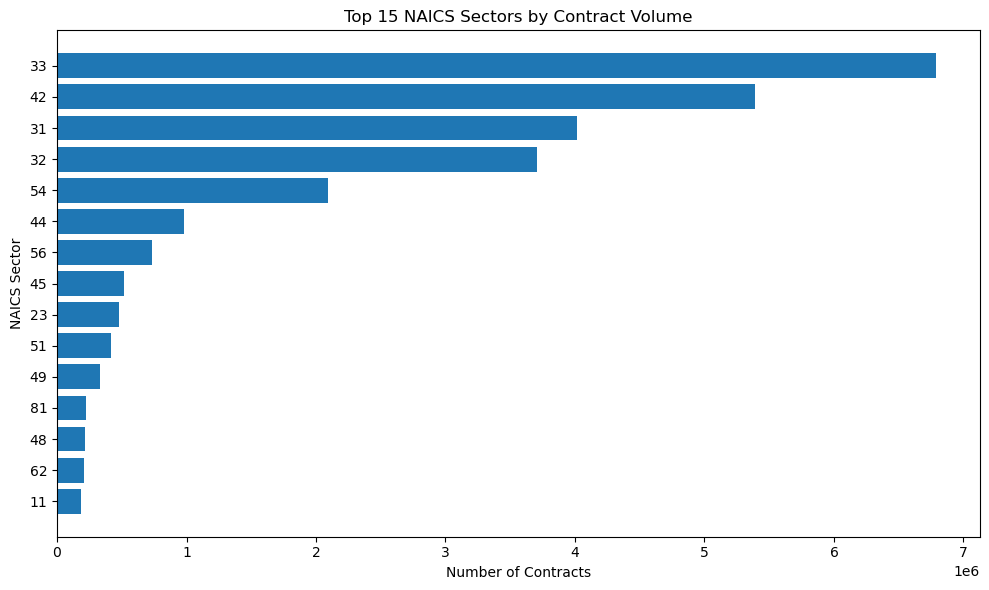

In [48]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
# Plot the top 15 NAICS sectors by number of contracts
plt.figure(figsize=(10, 6))
plt.barh(naics_pdf["naics2"], naics_pdf["contracts"])
plt.title("Top 15 NAICS Sectors by Contract Volume")
plt.xlabel("Number of Contracts")
plt.ylabel("NAICS Sector")
plt.tight_layout()
plt.show()

## Top awarding agencies

In [49]:
# Purpose: Aggregate contracts by awarding agency to analyze volume and target behavior.
# Summarize the top 15 awarding agencies by contract count, offers received, and median contract value
top_agencies = (eda_df.groupBy("awarding_agency_code", "awarding_agency_name").agg(
        F.count("*").alias("contracts"),

        F.avg(F.when(F.col("number_of_offers_received") >= 0, F.col("number_of_offers_received"))
        ).alias("avg_offers"),

        F.expr("""
            percentile_approx(
                CASE
                    WHEN number_of_offers_received >= 0
                    THEN number_of_offers_received
                END,
                0.5
            )
        """).alias("median_offers"),

        F.expr("""
            percentile_approx(
                CASE
                    WHEN base_and_all_options_value > 0
                    THEN base_and_all_options_value
                END,
                0.5
            )
        """).alias("median_contract_value"))
    .orderBy(F.desc("contracts"))
    .limit(15)
)

top_agencies.show(truncate=False)

+--------------------+---------------------------------------------+---------+------------------+-------------+---------------------+
|awarding_agency_code|awarding_agency_name                         |contracts|avg_offers        |median_offers|median_contract_value|
+--------------------+---------------------------------------------+---------+------------------+-------------+---------------------+
|097                 |Department of Defense                        |17175463 |12.128049858360502|2            |577.28               |
|047                 |General Services Administration              |5914026  |232.10175589150901|8            |151.12               |
|012                 |Department of Agriculture                    |974268   |7.280421852351677 |1            |14745.0              |
|036                 |Department of Veterans Affairs               |510445   |47.3065461803179  |1            |36050.09             |
|015                 |Department of Justice                   

In [50]:
# Purpose: Prepare `agency_pdf` for the next Big Data processing, analysis, or modeling step.
agency_pdf = (top_agencies.toPandas().sort_values("contracts"))

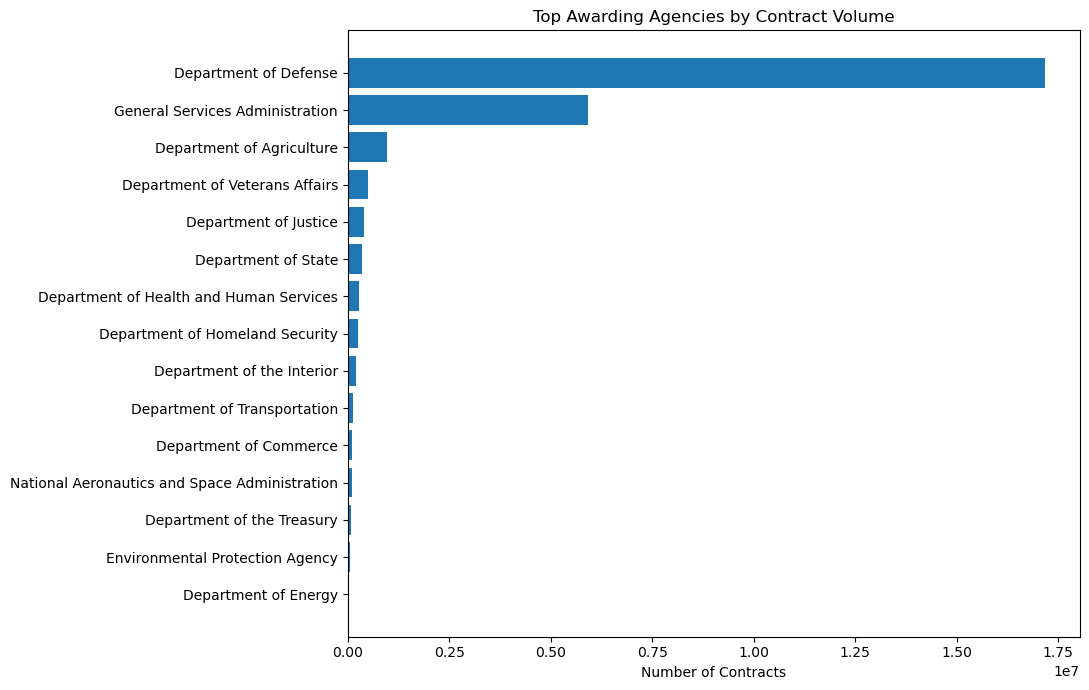

In [51]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
# Plot the top awarding agencies by number of contracts
plt.figure(figsize=(11, 7))
plt.barh(agency_pdf["awarding_agency_name"], agency_pdf["contracts"])
plt.title("Top Awarding Agencies by Contract Volume")
plt.xlabel("Number of Contracts")
plt.tight_layout()
plt.show()

## Competition type vs offers

In [52]:
# Purpose: Apply the required Spark column transformation for cleaning or feature engineering.
# Summarize contract competition levels by contract count, median offers, and average offers
competition_eda = (eda_df.withColumn("extent_competed",
        F.coalesce(F.col("extent_competed"), F.lit("__UNKNOWN__"))).groupBy("extent_competed").agg(
        F.count("*").alias("contracts"), F.expr("""
            percentile_approx(
                CASE
                    WHEN number_of_offers_received >= 0
                    THEN number_of_offers_received
                END,
                0.5
            )
        """).alias("median_offers"), F.avg(
            F.when(
                F.col("number_of_offers_received") >= 0,
                F.col("number_of_offers_received")
            )
        ).alias("avg_offers")
    )
    .orderBy(F.desc("contracts"))
)

In [54]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
competition_eda.show(30,truncate=False)

+----------------------------------------------------+---------+-------------+------------------+
|extent_competed                                     |contracts|median_offers|avg_offers        |
+----------------------------------------------------+---------+-------------+------------------+
|FULL AND OPEN COMPETITION                           |15799038 |5            |175.64602287200083|
|COMPETED UNDER SAP                                  |3906361  |2            |4.639465164559168 |
|FULL AND OPEN COMPETITION AFTER EXCLUSION OF SOURC  |2992579  |4            |36.272463961114624|
|NOT AVAILABLE FOR COMPETITION                       |1457668  |1            |1.0543114262905249|
|NOT COMPETED                                        |1447304  |1            |1.000376652979657 |
|NOT COMPETED UNDER SAP                              |917840   |1            |0.9978523114114309|
|FULL AND OPEN COMPETITION AFTER EXCLUSION OF SOURCES|128196   |3            |6.29975659686961  |
|__UNKNOWN__        

## Set-aside EDA

In [55]:
# Purpose: Apply the required Spark column transformation for cleaning or feature engineering.
# Summarize the top 15 set-aside types by contract count and median number of offers received
setaside_eda = (eda_df.withColumn("type_of_set_aside",
        F.coalesce(F.col("type_of_set_aside"), F.lit("__UNKNOWN__"))).groupBy("type_of_set_aside").agg(
        F.count("*").alias("contracts"), F.expr("""
            percentile_approx(
                CASE
                    WHEN number_of_offers_received >= 0
                    THEN number_of_offers_received
                END,
                0.5
            )
        """).alias("median_offers"))
    .orderBy(F.desc("contracts"))
    .limit(15)
)

In [56]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
setaside_eda.show(truncate=False)

+-------------------------------------------------------+---------+-------------+
|type_of_set_aside                                      |contracts|median_offers|
+-------------------------------------------------------+---------+-------------+
|__UNKNOWN__                                            |20428142 |5            |
|NO SET ASIDE USED.                                     |4767436  |1            |
|SMALL BUSINESS SET ASIDE - TOTAL                       |1150350  |3            |
|8(A) SOLE SOURCE                                       |151604   |1            |
|SERVICE DISABLED VETERAN OWNED SMALL BUSINESS SET-     |126856   |4            |
|8A COMPETED                                            |49506    |6            |
|SMALL BUSINESS SET ASIDE - PARTIAL                     |29387    |5            |
|HUBZONE SET-ASIDE                                      |24909    |4            |
|WOMEN OWNED SMALL BUSINESS                             |24338    |4            |
|SDVOSB SOLE SOU

# Relationship between contract value and offers

In [57]:
# Purpose: Apply the required Spark column transformation for cleaning or feature engineering.
# Filter valid target values and create log-transformed offers and award value features for relationship analysis
target_relationship = (eda_df.filter(F.col("number_of_offers_received") >= 0)
    .filter(F.col("base_and_all_options_value") > 0).withColumn("log_offers",
        F.log1p(F.col("number_of_offers_received"))).withColumn("log_award_value",
        F.log1p(F.col("base_and_all_options_value")))
)

In [58]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
target_relationship.select(F.corr("log_offers","log_award_value").alias("correlation")).show()

+--------------------+
|         correlation|
+--------------------+
|-0.17055361368047778|
+--------------------+



## PART B- DATA CLEANING

## Clean categorical strings

In [58]:
# Purpose: Inspect the Spark DataFrame schema before continuing with transformations.
contracts_df.printSchema()

root
 |-- id: string (nullable = true)
 |-- award_id: string (nullable = true)
 |-- piid: string (nullable = true)
 |-- parent_award_piid: string (nullable = true)
 |-- award_type: string (nullable = true)
 |-- extent_competed: string (nullable = true)
 |-- solicitation_procedures: string (nullable = true)
 |-- type_of_set_aside: string (nullable = true)
 |-- awarding_agency_code: string (nullable = true)
 |-- awarding_agency_name: string (nullable = true)
 |-- awarding_subagency_code: string (nullable = true)
 |-- funding_agency_name: string (nullable = true)
 |-- naics_code: string (nullable = true)
 |-- psc_code: string (nullable = true)
 |-- recipient_state: string (nullable = true)
 |-- recipient_country: string (nullable = true)
 |-- pop_state: string (nullable = true)
 |-- pop_country: string (nullable = true)
 |-- recipient_name: string (nullable = true)
 |-- recipient_name_normalized: string (nullable = true)
 |-- small_business_flag: boolean (nullable = true)
 |-- base_and_al

In [57]:
# Purpose: Prepare `CATEGORY_COLUMNS` for the next Big Data processing, analysis, or modeling step.
CATEGORY_COLUMNS = ["recipient_country" "award_type", "extent_competed", "solicitation_procedures",
    "type_of_set_aside", "funding_agency_name", "awarding_agency_code", "awarding_subagency_code", "naics_code",
    "psc_code",
    "recipient_state",
    "pop_state",
    "pop_country"
]

## clean and adjust the business_types 

In [15]:
# Purpose: Inspect the Spark DataFrame schema before continuing with transformations.
contracts_df.select("business_types").printSchema()
contracts_df.selectExpr("typeof(business_types) AS business_types_datatype").show(truncate=False)

root
 |-- business_types: array (nullable = true)
 |    |-- element: string (containsNull = true)



+-----------------------+
|business_types_datatype|
+-----------------------+
|array<string>          |
|array<string>          |
|array<string>          |
|array<string>          |
|array<string>          |
|array<string>          |
|array<string>          |
|array<string>          |
|array<string>          |
|array<string>          |
|array<string>          |
|array<string>          |
|array<string>          |
|array<string>          |
|array<string>          |
|array<string>          |
|array<string>          |
|array<string>          |
|array<string>          |
|array<string>          |
+-----------------------+
only showing top 20 rows



In [17]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
contracts_df.select("business_types").filter(F.col("business_types").isNotNull()).show(20, truncate=False)

26/08/18 14:20:03 WARN DataSourceScanExecUtil: Failed while estimating variable length type: ColumnPath [business_types] not found in the file's metadata.


+--------------+
|business_types|
+--------------+
+--------------+



In [25]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
contracts_df.select('business_types').show()

26/08/18 14:24:22 WARN DataSourceScanExecUtil: Failed while estimating variable length type: ColumnPath [business_types] not found in the file's metadata.


+--------------+
|business_types|
+--------------+
|          NULL|
|          NULL|
|          NULL|
|          NULL|
|          NULL|
|          NULL|
|          NULL|
|          NULL|
|          NULL|
|          NULL|
|          NULL|
|          NULL|
|          NULL|
|          NULL|
|          NULL|
|          NULL|
|          NULL|
|          NULL|
|          NULL|
|          NULL|
+--------------+
only showing top 20 rows



In [19]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
contracts_df.selectExpr("typeof(business_types)").show()

+----------------------+
|typeof(business_types)|
+----------------------+
|         array<string>|
|         array<string>|
|         array<string>|
|         array<string>|
|         array<string>|
|         array<string>|
|         array<string>|
|         array<string>|
|         array<string>|
|         array<string>|
|         array<string>|
|         array<string>|
|         array<string>|
|         array<string>|
|         array<string>|
|         array<string>|
|         array<string>|
|         array<string>|
|         array<string>|
|         array<string>|
+----------------------+
only showing top 20 rows



In [20]:
# Purpose: Apply the required Spark column transformation for cleaning or feature engineering.
silver_df = contracts_df.withColumn("business_types_clean", F.when(F.col("business_types").isNull(),
        F.array().cast("array<string>")).otherwise(F.col("business_types")))

In [21]:
# Purpose: Apply the required Spark column transformation for cleaning or feature engineering.
silver_df = silver_df.withColumn("business_type_count", F.size("business_types_clean"))

In [23]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
silver_df.select('business_type_count').show()

26/08/18 14:22:21 WARN DataSourceScanExecUtil: Failed while estimating variable length type: ColumnPath [business_types] not found in the file's metadata.


+-------------------+
|business_type_count|
+-------------------+
|                  0|
|                  0|
|                  0|
|                  0|
|                  0|
|                  0|
|                  0|
|                  0|
|                  0|
|                  0|
|                  0|
|                  0|
|                  0|
|                  0|
|                  0|
|                  0|
|                  0|
|                  0|
|                  0|
|                  0|
+-------------------+
only showing top 20 rows



In [24]:
# Purpose: Aggregate the Spark data to produce summary statistics for this analysis.
(silver_df.groupBy("business_type_count").count().orderBy("business_type_count").show(30, truncate=False))

26/08/18 14:22:44 WARN DataSourceScanExecUtil: Failed while estimating variable length type: ColumnPath [business_types] not found in the file's metadata.


+-------------------+--------+
|business_type_count|count   |
+-------------------+--------+
|0                  |26783674|
+-------------------+--------+



In [26]:
# Purpose: Load the required Parquet data into `staging_df` for this Big Data processing stage.
staging_df = spark.read.parquet(NORMALIZED_SPARK_ROOT)

In [28]:
# Purpose: Aggregate the Spark data to produce summary statistics for this analysis.
staging_df.groupby().count().show()

+--------+
|   count|
+--------+
|26837988|
+--------+

